## 微调预训练模型进行文本分类

In [1]:
%matplotlib inline

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
torch.set_printoptions(edgeitems=2)
torch.manual_seed(123456)

print("")

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

添加环境变量取消以后警告提示：
```
# huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
```

### 1. 加载数据集

In [3]:
ds_file_path = "../../../data/datasets/emotion/embedding_ds"

# 从磁盘中加载数据集
ds = load_from_disk(ds_file_path)

# 设置数据集数据的格式为torch
# ds.set_format("torch")

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
})

### 2. 微调预训练模型

#### 2.1 加载预训练模型

In [5]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

In [6]:
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
device

'mps'

In [7]:
# 加载预训练模型
# 我们的数据集标签有6个值
num_labels = 6
checkpoint = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


> 上面的警告信息是，说明模型的某些部分是随机初始化的。

In [8]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [9]:
tokenizer(ds["train"]["text"][0], return_tensors="pt")

{'input_ids': tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [10]:
# 使用模型进行个试算
inputs = tokenizer(ds["test"]["text"][0], return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}
outputs = model(**inputs)
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.0868, -0.2198,  0.1389, -0.3606, -0.3085, -0.4191]],
       device='mps:0', grad_fn=<LinearBackward0>), hidden_states=None, attentions=None)

In [11]:
outputs.loss, outputs["logits"].shape

(None, torch.Size([1, 6]))

In [12]:
outputs.keys()

odict_keys(['logits'])

#### 2.2 定义性能指标

为了在训练期间监控指标，我们需要为`Trainer`定义一个`compute_metrics()`函数。   
该函数接收一个`EvalPrediction`对象，并需要返回一个将每个指标名称映射到其值的字典。   

我们这里将计算模型的F1分数和准确率：

**1. 指标函数01**

In [13]:
import evaluate

def compute_metrics(eval_pred):
    # pred是transformers.trainer_utils.EvalPrediction得对象
    accuracy_metric = evaluate.load("accuracy")
    
    # 获取预测的值和真实的值
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)  # 得到最大值的索引

    # 返回计算的指标
    return accuracy_metric.compute(predictions=preds, references=labels)
    

**2. 指标函数02**

In [14]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics02(eval_pred):
    # pred是transformers.trainer_utils.EvalPrediction得对象
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)  # 得到最大值的索引
    # print(type(eval_pred), labels.shape, preds.shape)
    # print(labels[:5], preds[:5])   # [0 0 2 3 1] [0 0 2 3 1]
    
    f1 = f1_score(labels, preds, average="weighted")
    accuracy = accuracy_score(labels, preds)
    print(f"accuracy:{accuracy}, f1:{f1}\n")
    
    return {"accuracy": accuracy, "f1": f1}

#### 2.3 定义训练运行的所有超参数

In [15]:
from transformers import Trainer, TrainingArguments

In [16]:
batch_size = 64
logging_steps = len(ds["train"])

num_train_epochs = 3   # 训练周期数

model_output_dir = "../../../models/train/emotion"

trainning_args = TrainingArguments(
    output_dir=model_output_dir,            # 临时数据保存的路径
    num_train_epochs=num_train_epochs,      # 训练周期数，训练几轮
    learning_rate=1e-5,                     # 定义学习率
    per_device_train_batch_size=batch_size, # 定义训练的批次大小
    per_device_eval_batch_size=batch_size,  # 定义验证/测试的批次大小
    weight_decay=0.01,                      # 假如参数权重衰减，防止过拟合
    eval_strategy="epoch",                  # 定义测试执行的策略，可以取值为：no、epoch、steps
    disable_tqdm=False,                     # 是不是禁止tqdm进度条
    logging_steps=logging_steps,            # 记录日志的频率，每隔多少步记录一次日志
    push_to_hub=False,                      # 是否push模型到hub，需要先登录huggingface
    log_level="error"                       # 日志级别：debug,info,warning,error,critical,passive. 默认是warning
)

> 我们使用了`DataCollatorWithPadding`作为`data_collator`，它会自动填充输入序列，使它们具有相同的长度。这样可以确保在训练过程中，每个批次的输入数据具有一致的形状，便于模型处理。

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)

#### 2.4 训练

In [17]:
trainer = Trainer(
    model=model, 
    args=trainning_args,
    compute_metrics=compute_metrics,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,  
    # data_collator 它会自动填充输入序列，使它们具有相同的长度。这样可以确保在训练过程中，每个批次的输入数据具有一致的形状，便于模型处理。
)

**开始执行训练：** 训练会比较耗时。

In [18]:
# 记录一下耗时
%time trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.602106,0.791000
2,No log,0.311059,0.901500
3,No log,0.268044,0.912500


CPU times: user 1min 46s, sys: 20 s, total: 2min 6s
Wall time: 8min 11s


TrainOutput(global_step=750, training_loss=0.6093556722005208, metrics={'train_runtime': 491.4844, 'train_samples_per_second': 97.663, 'train_steps_per_second': 1.526, 'total_flos': 2141636459016960.0, 'train_loss': 0.6093556722005208, 'epoch': 3.0})

总共训练用了8分钟(不同机器配置耗时会不一样的)     
可以看到模型在验证集上的`Accuracy`分数是`91%`，也就是91%的准确率。真实微调模型的时候会把`num_train_epochs`调的更大一些。

In [19]:
# 查看checkpoint文件
!ls {model_output_dir}/checkpoint-500/

config.json             scheduler.pt            trainer_state.json
model.safetensors       special_tokens_map.json training_args.bin
optimizer.pt            tokenizer.json          vocab.txt
rng_state.pth           tokenizer_config.json


In [20]:
!du -smh {model_output_dir}

1.6G	../../../models/train/emotion


#### 2.5 评估模型

In [21]:
# 评估模型
eval_results = trainer.evaluate()

eval_results

{'eval_loss': 0.2680440843105316,
 'eval_accuracy': 0.9125,
 'eval_runtime': 8.1413,
 'eval_samples_per_second': 245.661,
 'eval_steps_per_second': 3.931,
 'epoch': 3.0}

In [22]:
# 我们使用验证集来验证一下
predict_outputs = trainer.predict(ds["validation"])
predict_outputs.metrics

{'test_loss': 0.2680440843105316,
 'test_accuracy': 0.9125,
 'test_runtime': 8.6137,
 'test_samples_per_second': 232.188,
 'test_steps_per_second': 3.715}

`predict()`方法输出一个`PredictionOutput`对象，其包含`predictions`和`label_ids`的数组，以及我们传递给训练器的度量指标`metrics`。

In [23]:
predict_outputs.predictions.shape, predict_outputs.label_ids.shape

((2000, 6), (2000,))

#### 2.6 绘制混淆矩阵

In [24]:
Y_predict = np.argmax(predict_outputs.predictions, axis=1)

In [25]:
Y_predict.shape

(2000,)

In [26]:
Y_predict[:5], ds["validation"]["label"][:5]

(array([0, 0, 2, 3, 1]), tensor([0, 0, 2, 3, 1]))

基于验证集的预测结果，再次绘制混淆矩阵：

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion_matrix: 用于计算混淆矩阵
# ConfusionMatrixDisplay：用于显示混淆矩阵

# 计算和可视化混淆矩阵，混淆矩阵是机器学习分类问题中常用的一个工具，用于衡量分类器性能。

def plot_confusion_matrix(y_predict, y_real_value, labels):
    # y_predict: 预测的分类标签值
    # y_real_value, 真实的分类标签值， 
    # labels：分类标签的名称，用于显示

    # 第1步：计算混淆矩阵: 
    # normalize有3个选择('true', 'pred', 'all'):
    # normalize= "true": 则返回的混淆矩阵会被归一化，使得每个元素表示的是该类别的真实样本被预测为该类别的概率
    cm = confusion_matrix(y_real_value, y_predict, normalize="true")
    
    # 第2步：开始画混淆矩阵图形
    # 2.1 创建绘图对象，图像大小是7,7
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # 2.2 创建ConfusionMatrixDisplay对象，用于后续的混淆矩阵可视化，传递要显示的混淆矩阵cm,指定混淆矩阵中类别标签labels
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # 2.2 绘制混淆矩阵，使用plot方法绘制混淆矩阵：
    # cmap设置渐变颜色，values_format="0.3f"设置矩阵中数值保留3位小数，ax=ax指定绘制的坐标轴，colorbar=False表示不现实颜色条
    display.plot(cmap="Greens", values_format=".3f", ax=ax, colorbar=False)
    
    # 2.3 设置标题：归一化的混淆矩阵
    plt.title("Normalized confusion matrix")
    
    # 2.4 显示图片
    plt.show()

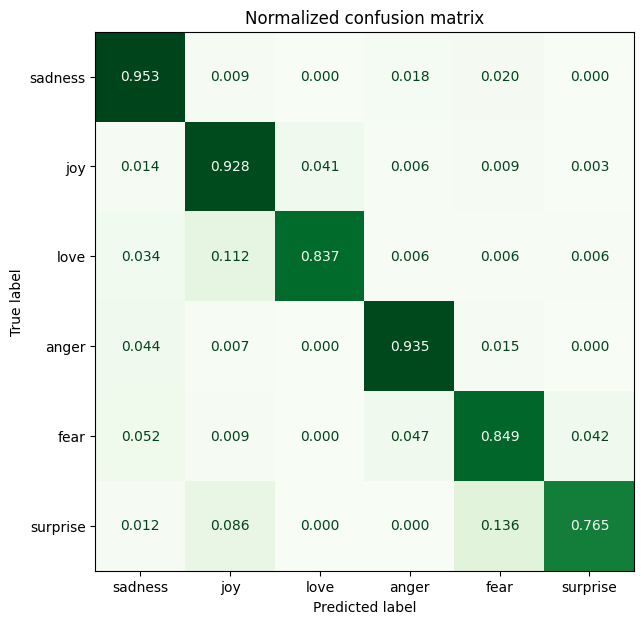

In [28]:
# 分类标签的值
labels = ds["train"].features["label"].names

# 绘制混淆矩阵
plot_confusion_matrix(Y_predict, ds["validation"]["label"].numpy(), labels)

通过上面的混淆矩阵，可以看出：    
- `love`容易与`joy`容易混淆
- `fear`容易与`surprise`或`anger`混淆
- `suprise`容易与`fear`或`joy`混淆。

### 3. 保存模型

In [29]:
# 保存模型
model.save_pretrained(f"{model_output_dir}/model-classfication")

In [30]:
tokenizer.save_pretrained(f"{model_output_dir}/model-classfication")

('../../../models/train/emotion/model-classfication/tokenizer_config.json',
 '../../../models/train/emotion/model-classfication/special_tokens_map.json',
 '../../../models/train/emotion/model-classfication/vocab.txt',
 '../../../models/train/emotion/model-classfication/added_tokens.json',
 '../../../models/train/emotion/model-classfication/tokenizer.json')